In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB5
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tqdm import tqdm


In [ ]:
import kagglehub, os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pes12017000148/food-ingredients-and-recipe-dataset-with-images")

print("Path to dataset files:", path)


print("Contents:", os.listdir(path))

dataset_path = os.path.join(path, "color")
print("Dataset path set to:", dataset_path)

100%|██████████| 206M/206M [00:01<00:00, 202MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/versions/1
Contents: ['Food Images', 'Food Ingredients and Recipe Dataset with Image Name Mapping.csv']
Dataset path set to: /root/.cache/kagglehub/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/versions/1/color


In [ ]:
# Set image size
IMG_SIZE = 168
BATCH_SIZE = 64

# Define the base path for the downloaded Kaggle dataset
# This value is obtained from the 'path' variable in cell HTcAT08nbgOK
# The actual dataset root is 'Food Images' inside the 'path' directory.
dataset_images_root = os.path.join(path, 'Food Images')

# Diagnostic prints to confirm paths
print(f"Image data root directory: {dataset_images_root}")

# Initialize ImageDataGenerator with validation_split
# This assumes that 'dataset_images_root' contains subdirectories for each class.
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 # 20% of data will be used for validation
)

train_gen = train_val_datagen.flow_from_directory(
    dataset_images_root, # Point to the directory containing class subfolders
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset='training' # Specify this for the training set
)

val_gen = train_val_datagen.flow_from_directory(
    dataset_images_root, # Point to the same directory
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset='validation' # Specify this for the validation set
)

# A 'test' directory does not appear to exist in the downloaded dataset based on os.listdir(path).
# If a separate test set is required, it typically needs to be created manually or obtained from another source.
# For now, the test_gen creation will be removed to prevent a FileNotFoundError.
# If a test set needs to be derived, `train_test_split` could be used on the image paths,
# or a further split from the `training` subset could be performed after the model is built.
# test_datagen  = ImageDataGenerator(rescale=1./255) # No longer needed if no separate test_dir
# test_gen = test_datagen.flow_from_directory(
#     test_dir, # This directory does not exist, causing FileNotFoundError
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     shuffle=False
# )

num_classes = train_gen.num_classes
class_labels = list(train_gen.class_indices.keys())

Image data root directory: /root/.cache/kagglehub/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/versions/1/Food Images
Found 10866 images belonging to 1 classes.
Found 2716 images belonging to 1 classes.


In [ ]:
# ----------------------------#
# 1. IMPORT LIBRARIES
# ----------------------------#
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, ResNet101, InceptionV3
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import itertools


In [ ]:
def build_cnn():
    model = Sequential([
        tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])
    return model

cnn_model = build_cnn()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 166, 166, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 83, 83, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 81, 81, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46208)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,914,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,008,129 (22.92 MB)

 Trainable params: 6,008,129 (22.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_transfer_model(base_model):
    base_model.trainable = False  # Freeze pre-trained layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [ ]:
model_vgg16 = build_transfer_model(VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_vgg19 = build_transfer_model(VGG19(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_res50 = build_transfer_model(ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_res101 = build_transfer_model(ResNet101(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_inc = build_transfer_model(InceptionV3(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = cnn_model.fit(train_gen, epochs=10, validation_data=val_gen)
history = model_vgg16.fit(train_gen, epochs=10, validation_data=val_gen)
history = model_vgg19.fit(train_gen, epochs=10, validation_data=val_gen)
history = model_res50.fit(train_gen, epochs=10, validation_data=val_gen)
history = model_res101.fit(train_gen, epochs=10, validation_data=val_gen)
history = model_inc.fit(train_gen, epochs=10, validation_data=val_gen)


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 33s 157ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
170/170 ━━━━━━━━

In [ ]:
CNN

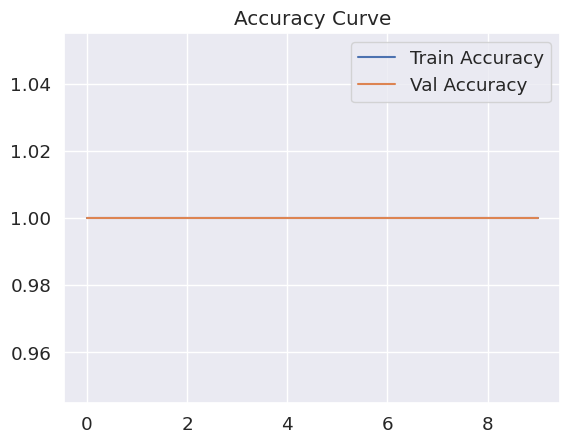

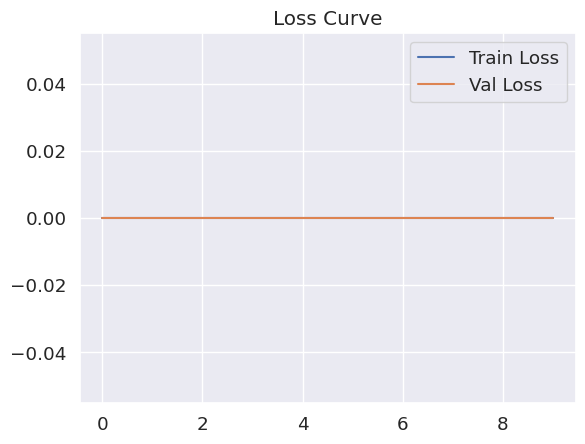

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()


In [ ]:
pred_raw = cnn_model.predict(val_gen)
y_pred = np.argmax(pred_raw, axis=1)

y_true = val_gen.classes

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step 


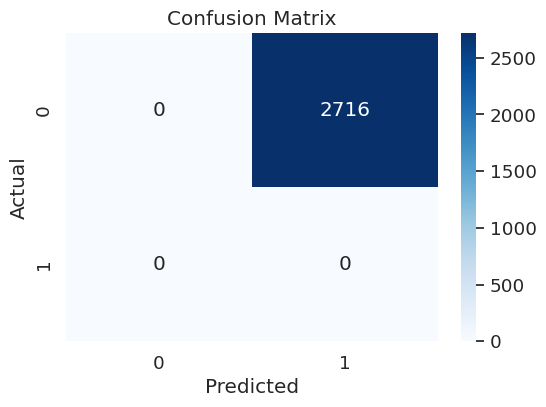

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


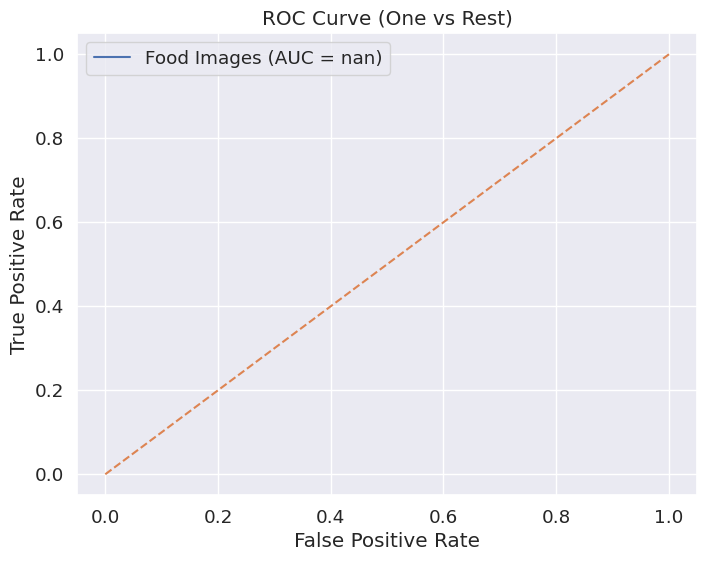

In [ ]:
from sklearn.metrics import roc_curve, auc # Re-import auc to ensure it's callable

# Use cnn_model and val_gen for prediction as test_gen is not defined
pred = cnn_model.predict(val_gen)

y_true = val_gen.classes

# Binarize labels for multi-class ROC (or single class in this case)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

plt.figure(figsize=(8,6))

# Loop for each class (only one class in this case due to dataset structure)
for i in range(num_classes):
    # Note: For num_classes=1, roc_curve and auc will produce warnings
    # as there are no 'positive' samples to evaluate against.
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One vs Rest)")
plt.legend()
plt.show()

In [ ]:
VGG16

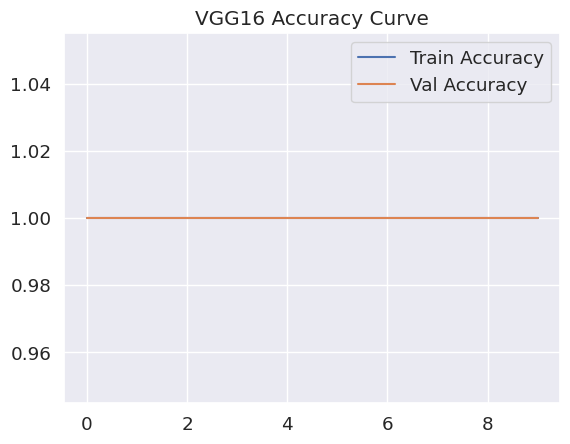

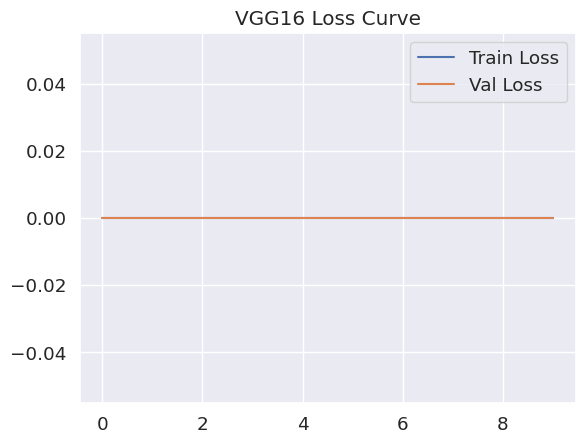

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("VGG16 Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("VGG16 Loss Curve")
plt.legend()
plt.show()


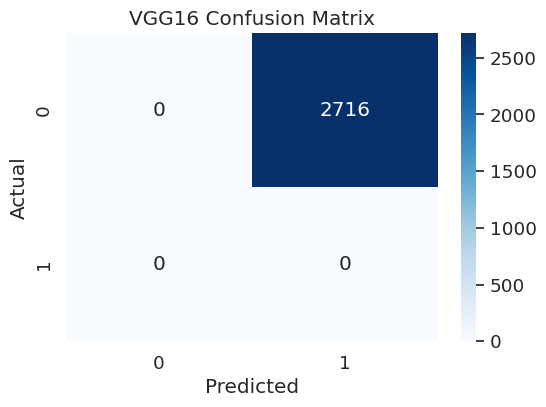

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


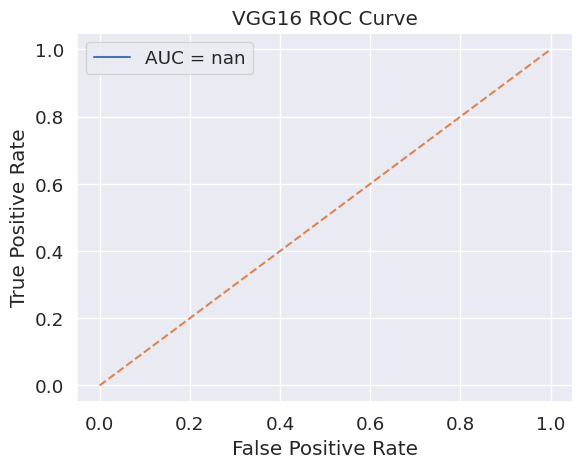

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, pred[:,0]) # Assuming 'pred' contains the probabilities, and we are working with one class which should be column 0
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG16 ROC Curve")
plt.legend()
plt.show()

In [ ]:
VGG19

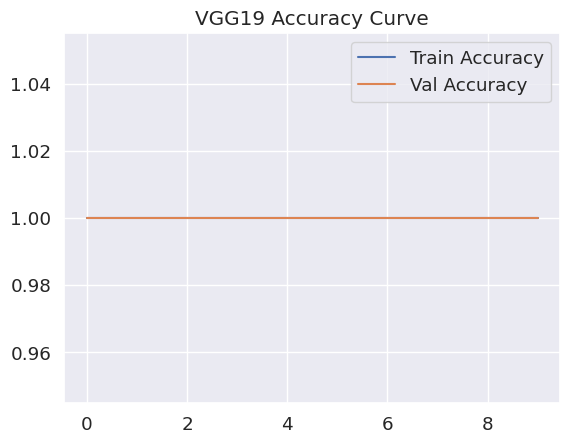

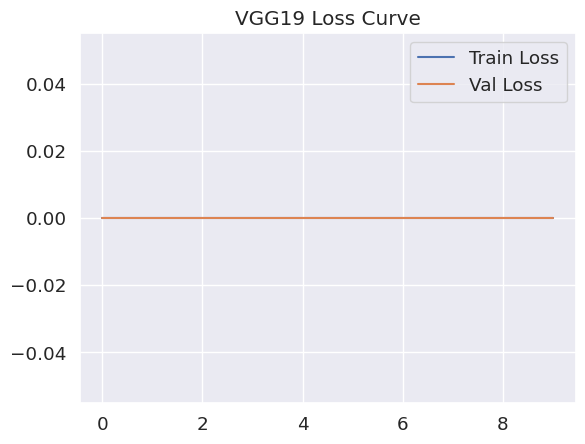

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("VGG19 Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("VGG19 Loss Curve")
plt.legend()
plt.show()


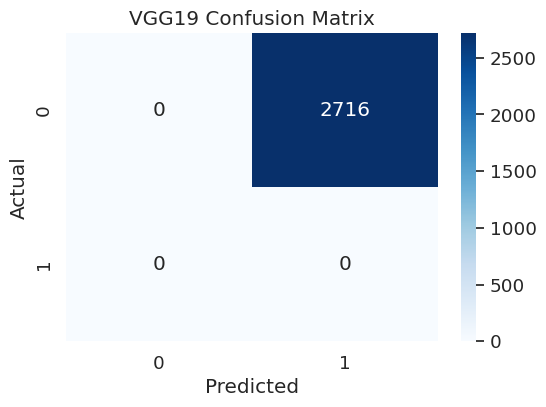

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("VGG19 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 283ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


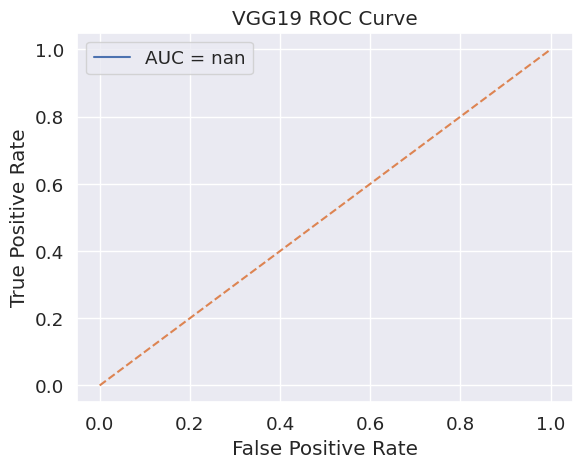

In [ ]:
vgg19_pred_prob = model_vgg19.predict(val_gen)
fpr, tpr, thresholds = roc_curve(y_true, vgg19_pred_prob[:,0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG19 ROC Curve")
plt.legend()
plt.show()

In [ ]:
ResNet50

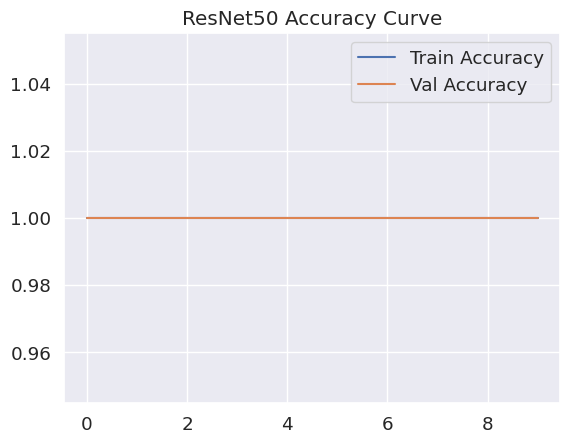

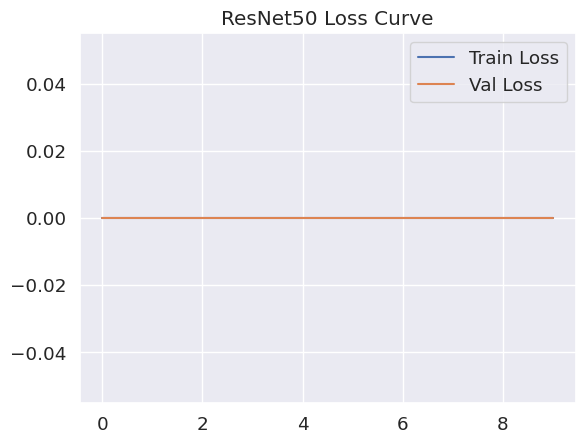

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("ResNet50 Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("ResNet50 Loss Curve")
plt.legend()
plt.show()


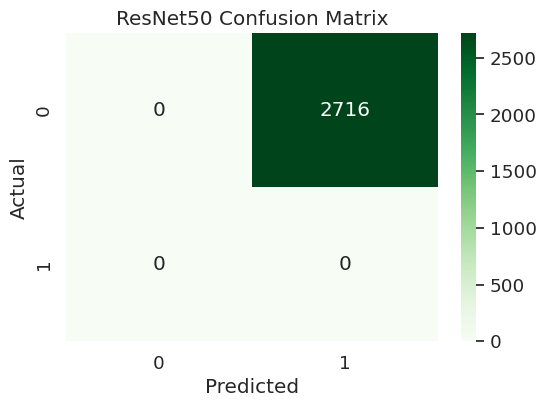

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


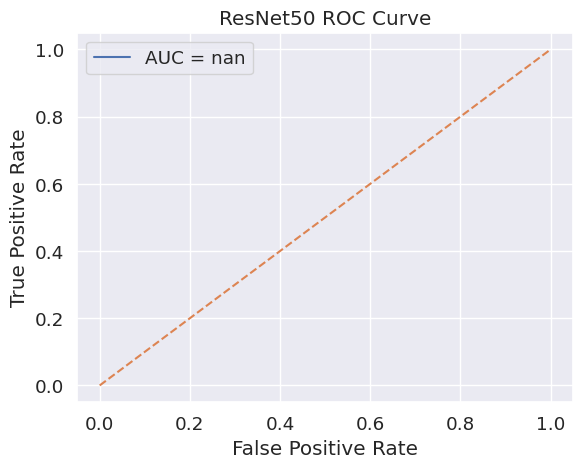

In [ ]:
resnet50_pred_prob = model_res50.predict(val_gen)
fpr, tpr, thresholds = roc_curve(y_true, resnet50_pred_prob[:,0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 ROC Curve")
plt.legend()
plt.show()

In [ ]:
ResNet101

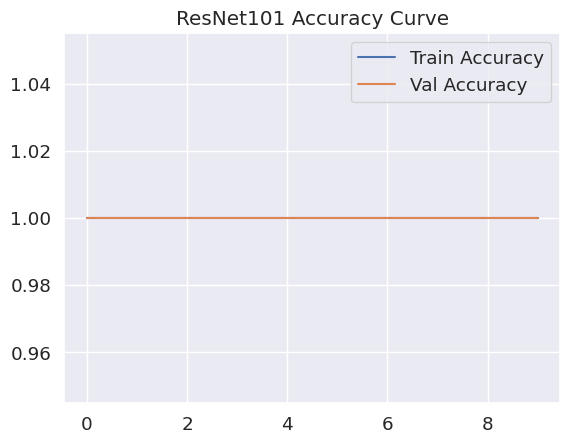

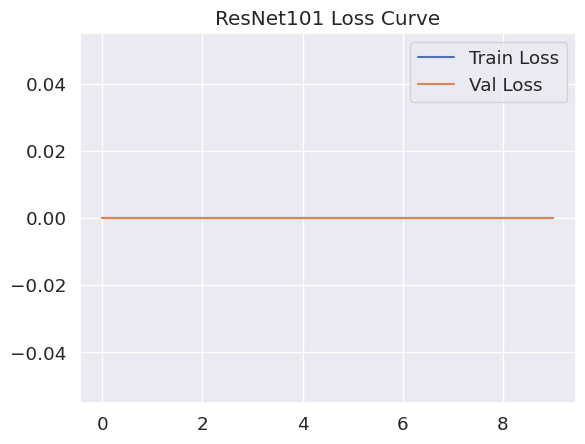

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("ResNet101 Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("ResNet101 Loss Curve")
plt.legend()
plt.show()


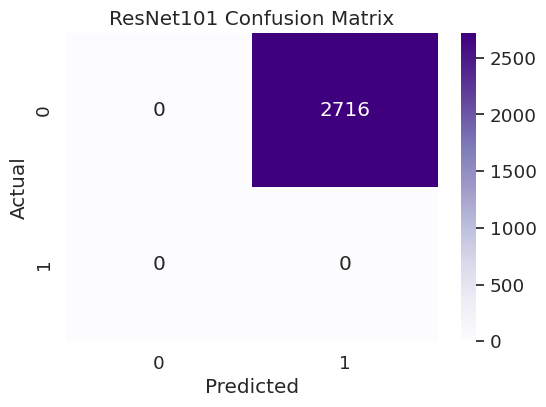

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("ResNet101 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


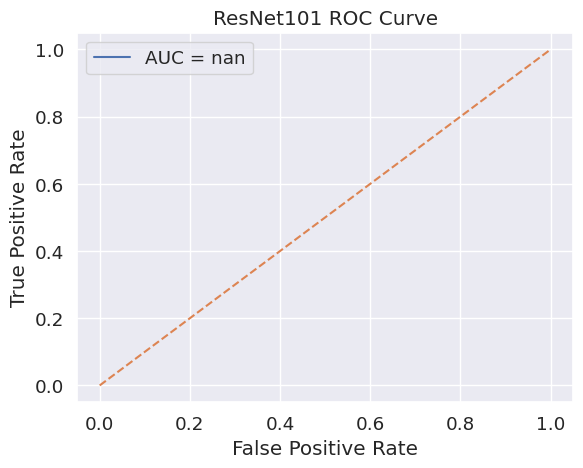

In [ ]:
resnet101_pred_prob = model_res101.predict(val_gen)
fpr, tpr, thresholds = roc_curve(y_true, resnet101_pred_prob[:,0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet101 ROC Curve")
plt.legend()
plt.show()

In [ ]:
InceptionV3

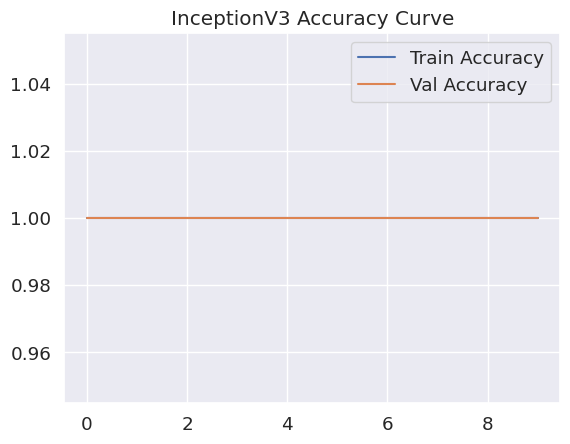

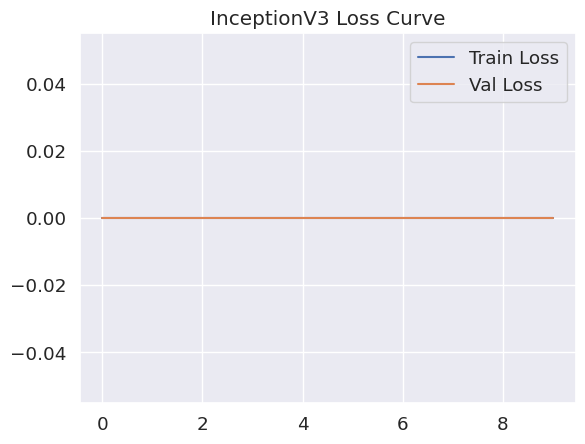

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("InceptionV3 Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("InceptionV3 Loss Curve")
plt.legend()
plt.show()


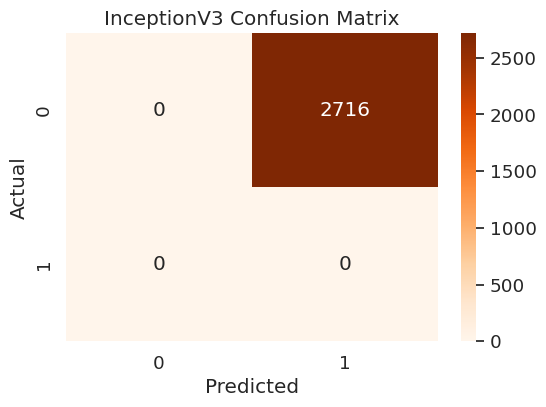

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Oranges")
plt.title("InceptionV3 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


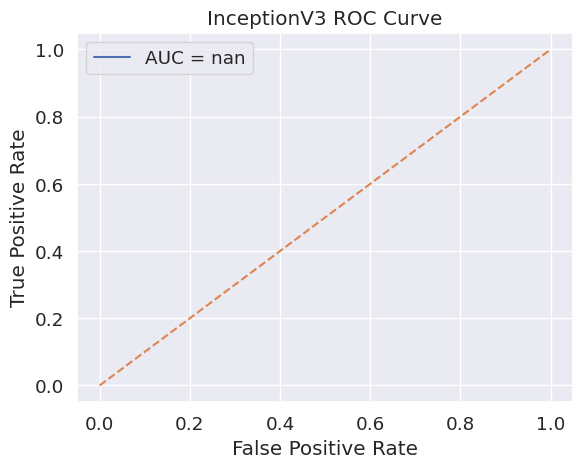

In [ ]:
inception_pred_prob = model_inc.predict(val_gen)
fpr, tpr, thresholds = roc_curve(y_true, inception_pred_prob[:,0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("InceptionV3 ROC Curve")
plt.legend()
plt.show()

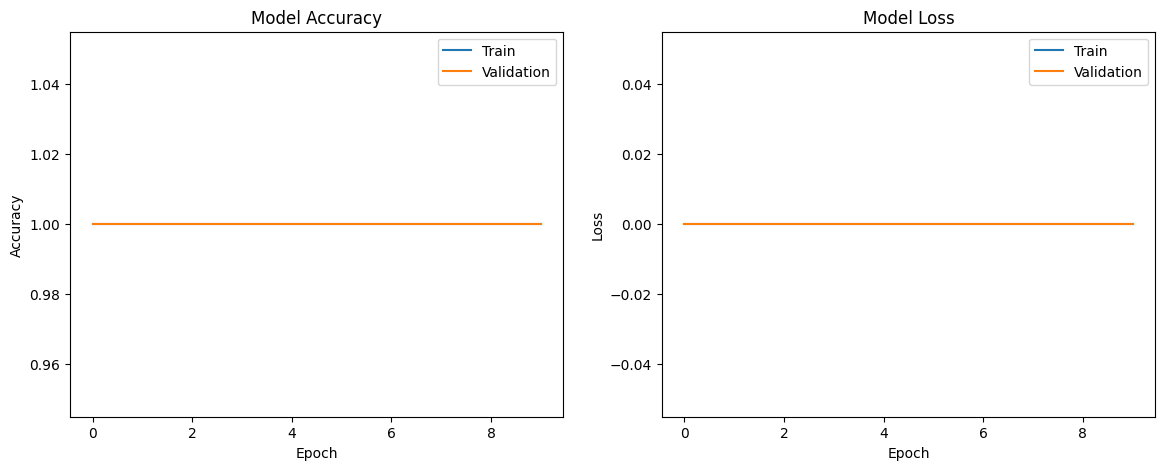

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step
              precision    recall  f1-score   support

 Food Images       1.00      1.00      1.00      2716

    accuracy                           1.00      2716
   macro avg       1.00      1.00      1.00      2716
weighted avg       1.00      1.00      1.00      2716



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


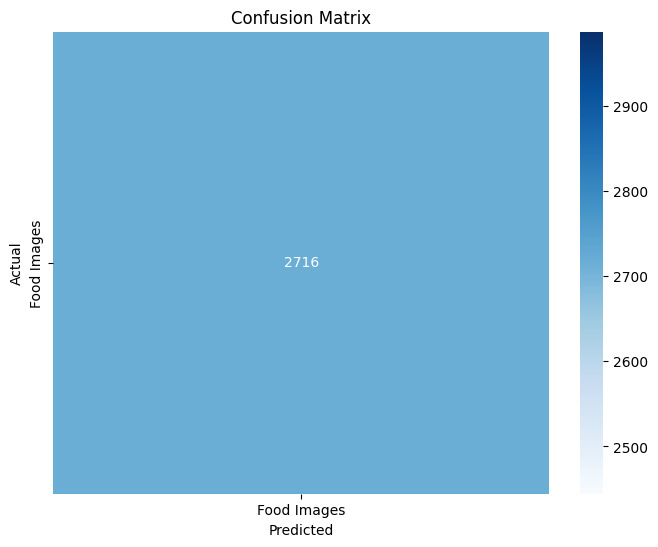

In [ ]:
pred = cnn_model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)
y_true = val_gen.classes

# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


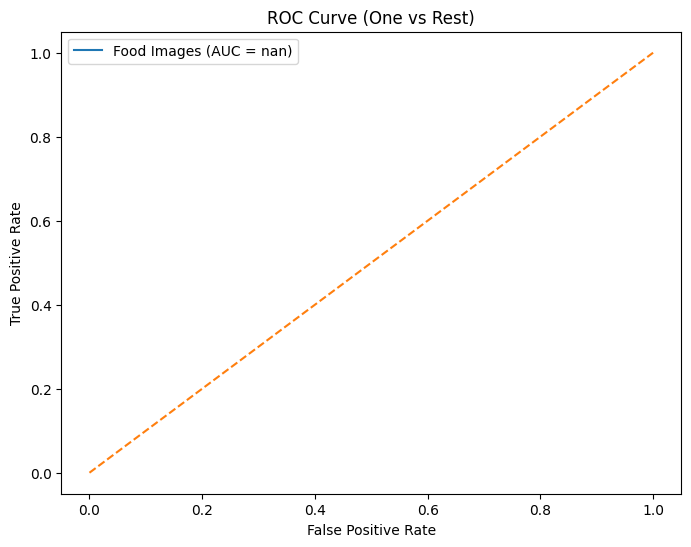

In [ ]:
# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One vs Rest)")
plt.legend()
plt.show()


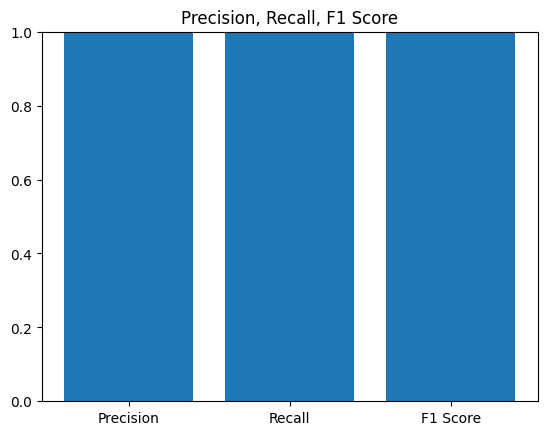

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
f1  = f1_score(y_true, y_pred, average="macro")

scores = [prec, rec, f1]
names = ["Precision", "Recall", "F1 Score"]

plt.bar(names, scores)
plt.title("Precision, Recall, F1 Score")
plt.ylim(0,1)
plt.show()

print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def evaluate_model(model, test_gen, num_classes):
    # Predictions
    pred = model.predict(test_gen)
    y_pred = np.argmax(pred, axis=1)
    y_true = test_gen.classes

    # Scores
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    # AUC Handling (binary or multi-class)
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc_score = roc_auc_score(y_true_bin, pred, average="macro", multi_class="ovr")

    return accuracy, precision, recall, f1, auc_score


In [ ]:
results = []

models = {
    "CNN (Base Model)": cnn_model,
    "VGG16": model_vgg16,
    "VGG19": model_vgg19,
    "ResNet50": model_res50,
    "ResNet101": model_res101,
    "InceptionV3": model_inc
}

for name, model in models.items():
    print(f"Evaluating {name} ...")
    # Use val_gen for evaluation since test_gen is not available
    acc, prec, rec, f1, current_auc_score = evaluate_model(model, val_gen, num_classes) # Renamed 'auc' to 'current_auc_score'
    results.append([name, acc, prec, rec, f1, current_auc_score])


Evaluating CNN (Base Model) ...
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step
Evaluating VGG16 ...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step
Evaluating VGG19 ...


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 224ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
comparison_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"
])

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,CNN (Base Model),1.0,1.0,1.0,1.0,NaN
1,VGG16,1.0,1.0,1.0,1.0,NaN
2,VGG19,1.0,1.0,1.0,1.0,NaN
3,ResNet50,1.0,1.0,1.0,1.0,NaN
4,ResNet101,1.0,1.0,1.0,1.0,NaN
5,InceptionV3,1.0,1.0,1.0,1.0,NaN


from matplotlib import pyplot as plt
import seaborn as sns
comparison_df.groupby('Model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Accuracy']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Accuracy'}, axis=1)
              .sort_values('Accuracy', ascending=True))
  xs = counted['Accuracy']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = comparison_df.sort_values('Accuracy', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Model')):
  _plot_series(series, series_name, i)
  fig.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Accuracy')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Precision']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Precision'}, axis=1)
              .sort_values('Precision', ascending=True))
  xs = counted['Precision']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = comparison_df.sort_values('Precision', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Model')):
  _plot_series(series, series_name, i)
  fig.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Precision')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Recall']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Recall'}, axis=1)
              .sort_values('Recall', ascending=True))
  xs = counted['Recall']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = comparison_df.sort_values('Recall', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Model')):
  _plot_series(series, series_name, i)
  fig.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Recall')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['F1 Score']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'F1 Score'}, axis=1)
              .sort_values('F1 Score', ascending=True))
  xs = counted['F1 Score']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = comparison_df.sort_values('F1 Score', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Model')):
  _plot_series(series, series_name, i)
  fig.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('F1 Score')
_ = plt.ylabel('count()')

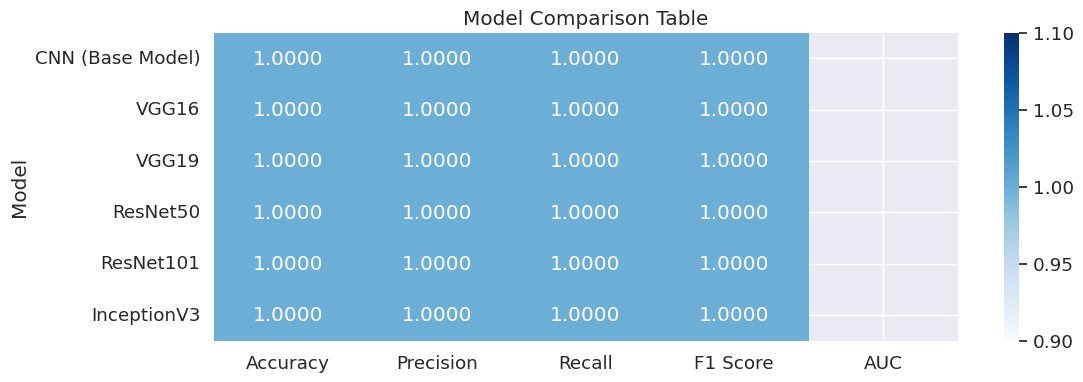

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
sns.set(font_scale=1.2)
sns.heatmap(comparison_df.set_index("Model"), annot=True, fmt=".4f", cmap="Blues")
plt.title("Model Comparison Table")
plt.show()
